In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

In [3]:
bands = [4, 5, 6, 7]


# all_bands    = ["Band 4 nterms2",  "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
# bands_naming = ['Band4_nterms2',   "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4 test',          "Band 5",      'Band 6', 'Band 7']

# band_to_index = {band: i for i, band in enumerate(all_bands)}

wavelengths = [lambda_mm[band] for band in bands]
lambda_bands_cm = mm_to_cm(wavelengths)
# print(lambda_bands_cm)

# colours = [alma_band_colors[band] for band in bands]

In [4]:
f_values = [1, 0.5, 0.3, 0.1]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.3': "dsharp_results_ff_0.30_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz",  
    '0.1': "dsharp_results_ff_0.10_smoothed_extrapol.npz"   
}


# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    for f in f_values:
        filename = prefix + band_prefix[band] + file_names[str(f)]
        d = np.load(filename)
        
        data[wav][str(f)] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.5e+02%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.5e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116

# $P\omega$  and $P\omega_{\text{eff}}$ vs maximum grain size

In [5]:
def plot_Pw_vs_grainsize(data, lambda_bands_cm, bands_labels = ['B4', 'B5', 'B6', 'B7'],
                         
                         porosity='1', albedo='w'):
    
    # Choose which P*omega quantity to plot
    if albedo == 'w':
        Pw_key = 'P_omega'
        ylabel = r'$P\omega$'
        save_name = f'Pw_vs_grainsize_f{porosity}.pdf'
        
    elif albedo == 'w_eff':
        Pw_key = 'P_omega_eff'
        ylabel = r'$P\omega_{\mathrm{eff}}$'
        save_name = f'Pw_eff_vs_grainsize_f{porosity}.pdf'
        
    else:
        raise ValueError("albedo must be 'w' or 'w_eff'")
    
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    for i, band in enumerate(bands):
        
        lam = wavelengths[i]
        
        ax.plot(
            cm_to_micron(data[lam][porosity]['a']),
            data[lam][porosity][Pw_key],
            color=alma_band_colors[band],
            ls='-',
            lw=2,
            label=f'{cm_to_mm(lambda_bands_cm[i]):.1f} mm'
                  if i != 3
                  else f'{cm_to_mm(lambda_bands_cm[i]):.2f} mm'
        )
        
        # Characteristic grain size
        a_char_micron = cm_to_micron(lambda_bands_cm[i] / (2 * np.pi))
        
        ax.axvline(
            a_char_micron,
            color=alma_band_colors[band],
            alpha=0.25,
            lw=2,
            ls='--'
        )
        
        # Find maximum
        max_idx = np.argmax(data[lam][porosity][Pw_key])
        max_val = data[lam][porosity][Pw_key][max_idx]
        amax_at_max = cm_to_micron(data[lam][porosity]['a'][max_idx])

        print(f'At Band {bands_labels[i]}, the highest Pw value is {max_val}')
        print(f'At this Pw value, the a_max value is {amax_at_max:.2f} micron')
        print(f'a_char_micron = {a_char_micron:.2f} micron')
        print()
    
    
    # Axis labels
    ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
    ax.set_ylabel(ylabel, fontsize=axis_label_fs)
    
    # Ticks
    ax.minorticks_on()

    ax.tick_params(axis="x", which="minor",
                   direction="in", left=True, right=True, length=4)
    ax.tick_params(axis="y", which="minor",
                   direction="in", left=True, right=True, length=4)

    ax.tick_params(axis="x", which="major",
                   direction="in", bottom=True, top=True,
                   length=7, labelsize=axis_num_fs)
    ax.tick_params(axis="y", which="major",
                   direction="in", left=True, right=True,
                   length=7, labelsize=axis_num_fs)

    # Log x-axis
    ax.set_xscale('log')

    # Remove scientific notation
    ax.xaxis.set_major_formatter(ScalarFormatter(zuseMathText=False))
    ax.ticklabel_format(style='plain', axis='x')

    # Characteristic grain size legend entry
    ax.axvline(
        -100,
        color='black',
        alpha=0.25,
        lw=2,
        ls='--',
        label=r'$a_{\mathrm{char}} = \lambda / 2\pi$'
    )

    ax.set_xlim(10, 1000)

    ax.legend(fontsize=legend_text_fs, frameon=False)

#     plt.savefig(
#         writeup_image_folder_path + '/DustModels/' + save_name,
#         dpi=300,
#         facecolor='white',
#         bbox_inches='tight'
#     )

    return fig, ax

At Band B4, the highest Pw value is 0.7275987190836268
At this Pw value, the a_max value is 266.02 micron
a_char_micron = 334.23 micron

At Band B5, the highest Pw value is 0.6955763349465576
At this Pw value, the a_max value is 196.46 micron
a_char_micron = 238.73 micron

At Band B6, the highest Pw value is 0.6837760063255338
At this Pw value, the a_max value is 173.46 micron
a_char_micron = 206.90 micron

At Band B7, the highest Pw value is 0.6487231023826352
At this Pw value, the a_max value is 120.70 micron
a_char_micron = 138.46 micron



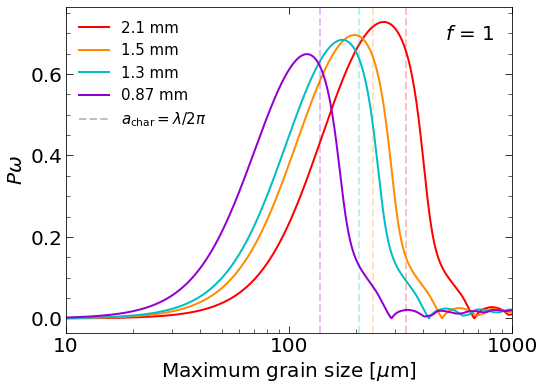

In [6]:
fig, ax = plot_Pw_vs_grainsize(data, lambda_bands_cm, porosity='1', albedo='w')
fs = 20

ax.text(0.85, 0.9, rf'$f$ = 1', transform=ax.transAxes, fontsize= fs)


plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_vs_grainsize_smooth.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

At Band B4, the highest Pw value is 0.7275720487351176
At this Pw value, the a_max value is 356.33 micron
a_char_micron = 334.23 micron

At Band B5, the highest Pw value is 0.6967494748426294
At this Pw value, the a_max value is 264.58 micron
a_char_micron = 238.73 micron

At Band B6, the highest Pw value is 0.6853868823113677
At this Pw value, the a_max value is 234.88 micron
a_char_micron = 206.90 micron

At Band B7, the highest Pw value is 0.6518600008008089
At this Pw value, the a_max value is 164.32 micron
a_char_micron = 138.46 micron



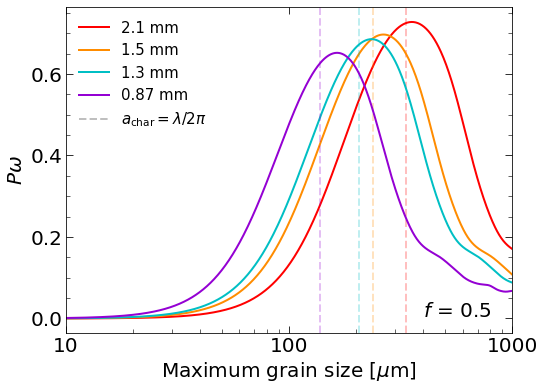

In [7]:
fig, ax = plot_Pw_vs_grainsize(data, lambda_bands_cm, porosity='0.5', albedo='w')
fs = 20

ax.text(0.8, 0.05, rf'$f$ = 0.5', transform=ax.transAxes, fontsize= fs)


plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_vs_grainsize_porous_smooth.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

At Band B4, the highest Pw value is 0.8409565725543404
At this Pw value, the a_max value is 307.88 micron
a_char_micron = 334.23 micron

At Band B5, the highest Pw value is 0.8085144967467731
At this Pw value, the a_max value is 223.71 micron
a_char_micron = 238.73 micron

At Band B6, the highest Pw value is 0.7960845525459214
At this Pw value, the a_max value is 196.46 micron
a_char_micron = 206.90 micron

At Band B7, the highest Pw value is 0.7578394407965862
At this Pw value, the a_max value is 134.50 micron
a_char_micron = 138.46 micron



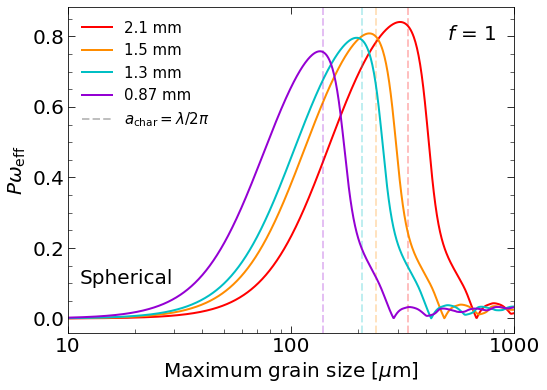

In [16]:
fig, ax = plot_Pw_vs_grainsize(data, lambda_bands_cm, porosity='1', albedo='w_eff')



ax.text(0.85, 0.9, rf'$f$ = 1', transform=ax.transAxes, fontsize= fs)

ax.text(0.025, 0.15, rf'Spherical', transform=ax.transAxes, fontsize= 20)

plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_eff_vs_grainsize_compact.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

At Band B4, the highest Pw value is 0.8723614814603368
At this Pw value, the a_max value is 464.55 micron
a_char_micron = 334.23 micron

At Band B5, the highest Pw value is 0.8433169939342153
At this Pw value, the a_max value is 339.38 micron
a_char_micron = 238.73 micron

At Band B6, the highest Pw value is 0.8320005915809826
At this Pw value, the a_max value is 298.04 micron
a_char_micron = 206.90 micron

At Band B7, the highest Pw value is 0.7968494114983047
At this Pw value, the a_max value is 204.05 micron
a_char_micron = 138.46 micron



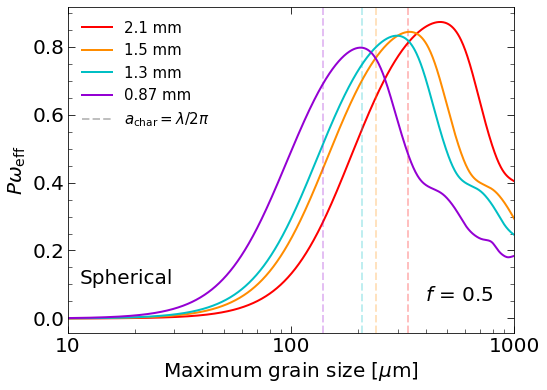

In [17]:
fig, ax = plot_Pw_vs_grainsize(data, lambda_bands_cm, porosity='0.5', albedo='w_eff')



ax.text(0.8, 0.1, rf'$f$ = 0.5', transform=ax.transAxes, fontsize= fs)

ax.text(0.025, 0.15, rf'Spherical', transform=ax.transAxes, fontsize= 20)

plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_eff_vs_grainsize_porous_smooth.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 